# PINN for the 1D Burger's equation

$$
\frac{\partial u}{\partial t}
+ u \frac{\partial u}{\partial x}
= \nu \frac{\partial^2 u}{\partial x^2},
\qquad
\nu = 0.
$$

with boundary conditions
$$
u(t,-1) = u(t,1) = 0,
$$

and initial condition
$$
u(0,x) = -\sin(\pi x).
$$

The space–time domain is
$$
\Omega = [0,1] \times [-1,1].
$$


In [3]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.io as sio
import itertools
import time
import pandas as pd
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [4]:
ALPHA = 0.1
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX = 0.0, 4.0


data = sio.loadmat("burgers_shock.mat")

x_ref = torch.tensor(data["x"], dtype=torch.float32).squeeze() 
t_ref = torch.tensor(data["t"], dtype=torch.float32).squeeze()     
u_ref = torch.tensor(data["usol"], dtype=torch.float32)
# enforce u_ref shape = (Nt, Nx)
if u_ref.shape == (len(x_ref), len(t_ref)):
    u_ref = u_ref.T
print("x_ref", data["x"].shape)
print("t_ref", data["t"].shape)
print("u_ref", data["usol"].shape)
@torch.no_grad()
def exact_solution(x, t):
    xq = x.detach().cpu().squeeze(1)   
    tq = t.detach().cpu().squeeze(1)  

    ix = torch.argmin(torch.abs(x_ref[:, None] - xq[None, :]), dim=0)  
    it = torch.argmin(torch.abs(t_ref[:, None] - tq[None, :]), dim=0)  

    y = u_ref[it, ix].unsqueeze(1) 
    return y.to(x.device)

def initial_condition_parabolic(x):
    return torch.tanh(x)

def sample_interior(n):
    x = torch.rand(n, 1, device=device) * (X_MAX - X_MIN) + X_MIN
    t = torch.rand(n, 1, device=device) * (T_MAX - T_MIN) + T_MIN
    return x, t

def sample_initial(n):
    x = torch.rand(n, 1, device=device) * (X_MAX - X_MIN) + X_MIN
    t = torch.zeros_like(x) + T_MIN
    return x, t

def sample_boundary(n):
    t_left = torch.rand(n, 1, device=device) * (T_MAX - T_MIN) + T_MIN
    t_right = torch.rand(n, 1, device=device) * (T_MAX - T_MIN) + T_MIN
    x_left = torch.zeros_like(t_left) + X_MIN
    x_right = torch.zeros_like(t_right) + X_MAX
    return (x_left, t_left), (x_right, t_right)


x_ref (256, 1)
t_ref (100, 1)
u_ref (256, 100)


FVM grids: (128,) (128,) (128, 128)


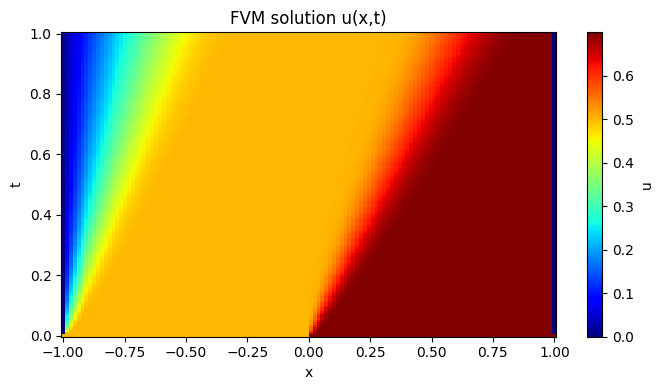

In [5]:
# FVM baseline to generate experimental data
def solve_burgers_fvm(nx=256, nt_out=101, x_min=-1.0, x_max=1.0, t_max=4.0,
                      nu=0.01/np.pi, cfl=0.4, noise_std=0.0, seed=42):
    '''
    nx - number of grid points
    nt_out - number of time steps/points
    x_min, x_max - spatial domain boundaries
    t_max - max time
    nu - viscosity term, not needed when hyperbolic
    cfl - some special number, controls dt
    noise, seed - self explanatory
    ut + 1/2(u)^2 = vuxx - if i set nu =0 then hyperbolic
    '''
    
    rng = np.random.default_rng(seed) # random number generator for reproducibility, if you remove seed every run would look slightly different 
    x = np.linspace(x_min, x_max, nx) # grid
    dx = x[1] - x[0] # spacing delta x, the grid is uniform, spacing is constant

    # Initial condition consistent with the classic Burgers setup
    u = np.where(x > 0.0, 0.7, 0.5) #causes the shock
    #u[0] = 10.0
    #u[-1] = 0.0
    
    t_out = np.linspace(0.0, t_max, nt_out) # time sample array, time at which i want to store solutions
    u_hist = np.zeros((nt_out, nx), dtype=np.float32) # placeholder for valuations 
    u_hist[0] = u # initial lcondition in, at t=0 the solution is the initial condition

    t = 0.0 # actual simulation time
    k = 1 # index of the next output time to fill in u_hist, u_hist[0] already stores time 0; next snapshot should go into u_hist[1]

     
    # it chooses the biggest feasible time step
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u))) # wave speed is f'(u) = u so the fastest signl travels at speed max u
        dt_adv = cfl * dx / umax # cfl condition
        if nu > 0.0:
            dt_diff = 0.5 * dx * dx / nu
        else: # if nu = 0 
            dt_diff = np.inf
        dt = min(dt_adv, dt_diff, t_max - t) #

        # Godunov flux for Burgers 
        uL = u[:-1]
        uR = u[1:]
        #PDE
        fL = 0.5 * uL * uL
        fR = 0.5 * uR * uR
       # flux is nonlinear and convex so the sol between ul and ur is either a rarefaction wave (ul< ur) or a shock wave 
        rare = uL <= uR
        fhat = np.empty_like(uL)
        # burgers and flip cause it's convex
        # Rarefaction: take min flux over uL and uR
        fhat[rare] = np.where(
            uL[rare] >= 0.0, fL[rare],
            np.where(uR[rare] <= 0.0, fR[rare], 0.0)
        )

        # Shock: shock speed s = 0.5 * (uL + uR)
        shock = ~rare # ul > ur
        s = 0.5 * (uL + uR) # refer to math formula expansion
        fhat[shock] = np.where(s[shock] >= 0.0, fL[shock], fR[shock]) # gudonov shock so if s>=0 then shock moves right and use left flux
        # ----------------------
        u_new = u.copy()
        if nu > 0.0: #VISCOUS CASE
            u_new[1:-1] = (
                u[1:-1]
                - (dt / dx) * (fhat[1:] - fhat[:-1]) # do update, it computes flux difference fr each cell
                + (nu * dt / (dx * dx)) * (u[2:] - 2.0 * u[1:-1] + u[:-2]) # viscorsity term
            )
        else:
            u_new[1:-1] = (
                u[1:-1]
                - (dt / dx) * (fhat[1:] - fhat[:-1]) # standard update as discussed
            )
        u_new[0] = 0.0 #CB periodic dirichlet conditions, 
        u_new[-1] = 0.0
        #step
        u = u_new
        t += dt
        # for nice consistent graphs, stopping condition
        while k < nt_out and t >= t_out[k] - 1e-12: 
            u_hist[k] = u
            k += 1
    #replace u(x,t) with u(x,t) +epsilon(x,t)
    if noise_std > 0.0:
        u_hist = u_hist + noise_std * rng.standard_normal(u_hist.shape)

    return x, t_out, u_hist


x_fvm, t_fvm, u_fvm = solve_burgers_fvm(nx=128, nt_out=128, noise_std=0.0, nu = 0, t_max = 1.0)


#x_fvm, t_fvm, u_fvm = solve_burgers_fvm(nx=128, nt_out=128, noise_std=0.0, nu = 0, t_max = 1.0)
print('FVM grids:', x_fvm.shape, t_fvm.shape, u_fvm.shape)
#nx spatial reoslution
#nt_out: number of time steps at which the solution is recorded

# Assuming u_fvm is (nt_out, nx)
plt.figure(figsize=(7, 4))

plt.pcolormesh(x_fvm, t_fvm, u_fvm, shading='auto', cmap='jet')

plt.xlabel('x')
plt.ylabel('t')
plt.title('FVM solution u(x,t)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()

FVM grids: (128,) (128,) (128, 128)


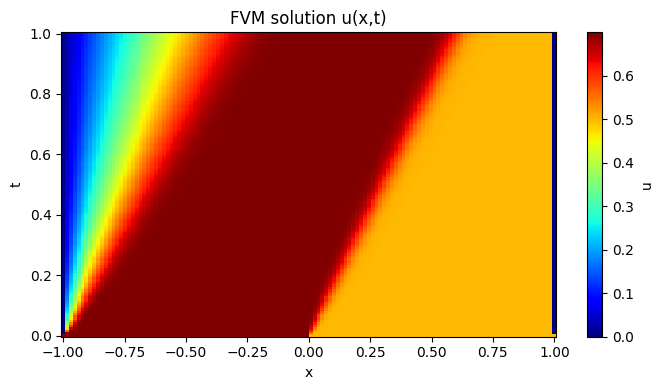

In [6]:
import numpy as np
import matplotlib.pyplot as plt



def godunov_flux(u):
    # Godunov flux for Burgers 
    uL = u[:-1]
    uR = u[1:]
    #PDE
    fL = 0.5 * uL * uL
    fR = 0.5 * uR * uR

    # flux is nonlinear and convex so the sol between ul and ur is either a rarefaction wave (ul< ur) or a shock wave 
    rare = uL <= uR
    fhat = np.empty_like(uL)

    # burgers and flip cause it's convex
    # Rarefaction: take min flux over uL and uR
    fhat[rare] = np.where(
        uL[rare] >= 0.0, fL[rare],
        np.where(uR[rare] <= 0.0, fR[rare], 0.0)
    )

    # Shock: shock speed s = 0.5 * (uL + uR)
    shock = ~rare # ul > ur, flip
    s = 0.5 * (uL + uR) # refer to math formula expansion
    fhat[shock] = np.where(
        s[shock] >= 0.0, fL[shock], fR[shock]
    ) # gudonov shock so if s>=0 then shock moves right and use left flux

    return fhat


def compute_time_step(u, dx, cfl, nu, t, t_max):
    umax = max(1e-6, np.max(np.abs(u))) # wave speed is f'(u) = u so the fastest signl travels at speed max u
    dt_adv = cfl * dx / umax # cfl condition

    if nu > 0.0:
        dt_diff = 0.5 * dx * dx / nu
    else: # if nu = 0 
        dt_diff = np.inf

    dt = min(dt_adv, dt_diff, t_max - t) #
    return dt


def solve_burgers_fvm(nx=256, nt_out=101, x_min=-1.0, x_max=1.0, t_max=4.0,
                      nu=0.01/np.pi, cfl=0.4, noise_std=0.0, seed=42):
    '''
    nx - number of grid points
    nt_out - number of time steps/points
    x_min, x_max - spatial domain boundaries
    t_max - max time
    nu - viscosity term, not needed when hyperbolic
    cfl - some special number, controls dt
    noise, seed - self explanatory
    ut + 1/2(u)^2 = vuxx - if i set nu =0 then hyperbolic
    '''

    rng = np.random.default_rng(seed) # random number generator for reproducibility, if you remove seed every run would look slightly different 
    
    x = np.linspace(x_min, x_max, nx) # grid
    dx = x[1] - x[0] # spacing delta x, the grid is uniform, spacing is constant

    # Initial condition consistent with the classic Burgers setup
    u = np.where(x < 0.0, 0.7, 0.5) #causes the shock
    #u[0] = 10.0
    #u[-1] = 0.0
    
    t_out = np.linspace(0.0, t_max, nt_out) # time sample array, time at which i want to store solutions
    u_hist = np.zeros((nt_out, nx), dtype=np.float32) # placeholder for valuations 
    u_hist[0] = u # initial lcondition in, at t=0 the solution is the initial condition

    t = 0.0 # actual simulation time
    k = 1 # index of the next output time to fill in u_hist, u_hist[0] already stores time 0; next snapshot should go into u_hist[1]

    # it chooses the biggest feasible time step
    while k < nt_out:

        dt = compute_time_step(u, dx, cfl, nu, t, t_max)

        fhat = godunov_flux(u)

        u_new = u.copy()
        u_new[1:-1] = ( u[1:-1] - (dt / dx) * (fhat[1:] - fhat[:-1])) # standard update

        u_new[0] = 0.0 #CB periodic dirichlet conditions, 
        u_new[-1] = 0.0

        #step
        u = u_new
        t += dt

        # for nice consistent graphs, stopping condition
        while k < nt_out and t >= t_out[k] - 1e-12: 
            u_hist[k] = u
            k += 1

    #replace u(x,t) with u(x,t) +epsilon(x,t)
    if noise_std > 0.0:
        u_hist = u_hist + noise_std * rng.standard_normal(u_hist.shape)

    return x, t_out, u_hist


# Run solver
x_fvm, t_fvm, u_fvm = solve_burgers_fvm(
    nx=128, nt_out=128, noise_std=0.0, nu=0, t_max=1.0
)

print('FVM grids:', x_fvm.shape, t_fvm.shape, u_fvm.shape)

plt.figure(figsize=(7, 4))
plt.pcolormesh(x_fvm, t_fvm, u_fvm, shading='auto', cmap='jet')
plt.xlabel('x')
plt.ylabel('t')
plt.title('FVM solution u(x,t)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes):
        super(SpectralConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes  # Number of Fourier modes to retain

        # Weights are complex numbers
        self.weights = nn.Parameter(torch.complex(
            torch.rand(in_channels, out_channels, modes),
            torch.rand(in_channels, out_channels, modes)
        ) * (1 / (in_channels * out_channels)))

    def forward(self, x):
        # x shape: (batch, channels, x_grid)
        batchsize = x.shape[0]
        
        # Compute Fourier coefficients
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes by learnable weights
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1, device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes] = torch.einsum("bix,iox->box", x_ft[:, :, :self.modes], self.weights)

        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

class FNO1d(nn.Module):
    def __init__(self, modes, width):
        super(FNO1d, self).__init__()
        self.modes = modes
        self.width = width
        
        # Project input (u0, x) to higher dimension
        self.fc0 = nn.Linear(2, self.width) 

        # Spectral Layers
        self.conv0 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes)
        
        # Standard 1x1 convolutions for the "skip" connections
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)

        # Fully connected projection back to output
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # x: (batch, nx, 2) where 2 is (u0, x_coordinate)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        
        x = self.fc0(x)
        x = x.permute(0, 2, 1)

        # Layer 0
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1 + x2)

        # Layer 1
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1 + x2)

        # Layer 2
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1 + x2)

        x = x.permute(0, 2, 1)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

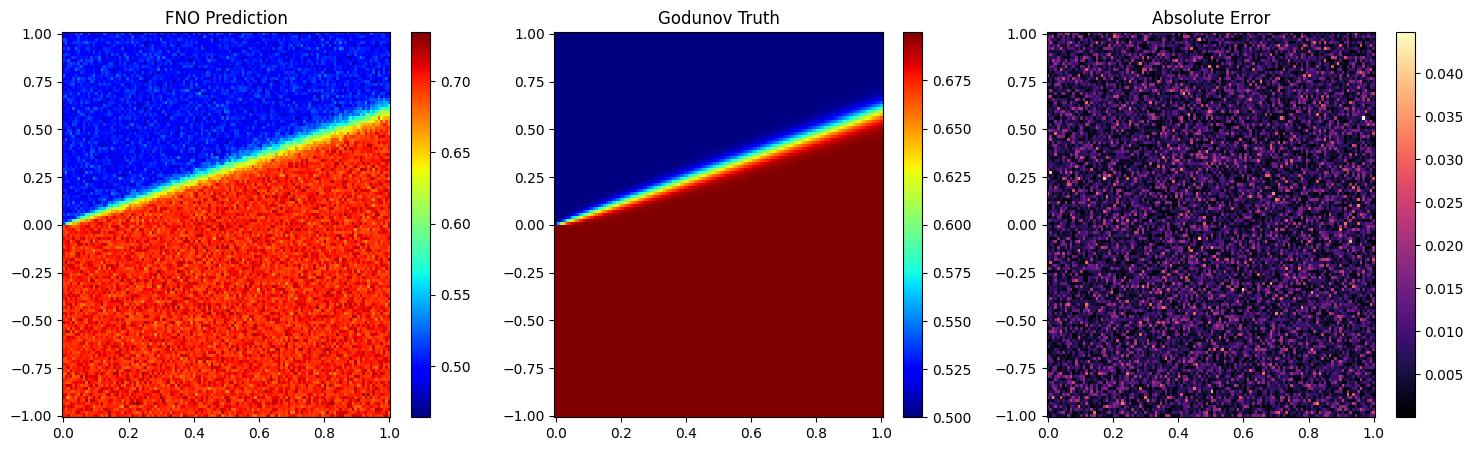

In [105]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- 1. Generate Godunov FVM Truth Data ---
# Using your solve_burgers_fvm and godunov_flux functions
x_fvm, t_fvm, u_truth = solve_burgers_fvm(
    nx=128, nt_out=128, noise_std=0.0, nu=0.0, t_max=1.0
)

# --- 2. Prepare FNO Prediction ---
# FNO expects input shape [Batch, NX, 1]. We use the first time step (t=0) as input.
u0 = torch.tensor(u_truth[0, :], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

# Ensure the model is in evaluation mode
fno_model.eval()
with torch.no_grad():
    # Model generates the full trajectory [Batch, NT, NX]
    u_pred_torch = fno_model(u0) 
    u_pred = u_pred_torch.squeeze(0).cpu().numpy()

# --- 3. Calculate Absolute Error ---
error = np.abs(u_truth - u_pred)

# --- 4. Plotting (Three-Panel Comparison) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot FNO Prediction
im0 = axes[0].pcolormesh(t_fvm, x_fvm, u_pred.T, shading='auto', cmap='jet')
axes[0].set_title('FNO Prediction')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
plt.colorbar(im0, ax=axes[0])

# Plot FVM Truth (Godunov)
im1 = axes[1].pcolormesh(t_fvm, x_fvm, u_truth.T, shading='auto', cmap='jet')
axes[1].set_title('Godunov FVM Truth')
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
plt.colorbar(im1, ax=axes[1])

# Plot Absolute Error
im2 = axes[2].pcolormesh(t_fvm, x_fvm, error.T, shading='auto', cmap='magma')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('t')
axes[2].set_ylabel('x')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [35]:
# In solver.py
def solve_burgers_fvm(u_init, nx=256, nt_out=101, x_min=-1.0, x_max=1.0, 
                      t_max=1.0, nu=0.0, cfl=0.4):
    x = np.linspace(x_min, x_max, nx)
    dx = x[1] - x[0]

    # Use the passed u_init instead of hardcoding u = np.where(...)
    u = u_init.copy() 
    
    t_out = np.linspace(0.0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u

    t = 0.0
    k = 1
    while k < nt_out:
        dt = compute_time_step(u, dx, cfl, nu, t, t_max)
        u_ext = add_ghost_cells(u) # Ensure you use the ghost cell helper
        fhat = godunov_flux(u_ext)

        u_new = u - (dt / dx) * (fhat[1:] - fhat[:-1])
        u = u_new
        t += dt

        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u
            k += 1

    return x, t_out, u_hist

FVM grids: (512,) (128,) (128, 512)


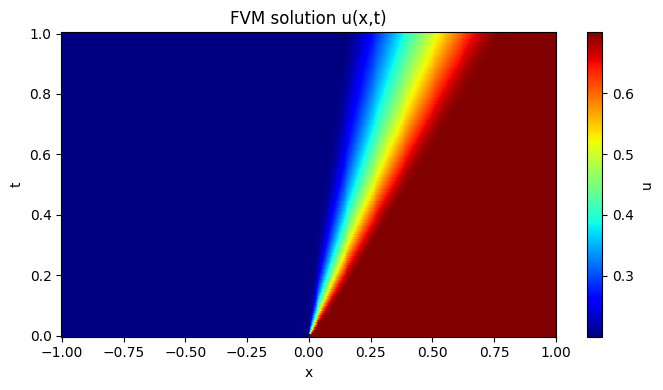

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#
def godunov_flux(u):
    # Godunov flux for Burgers 
    uL = u[:-1]
    uR = u[1:]

    # PDE flux f(u) = 1/2 u^2
    fL = 0.5 * uL * uL
    fR = 0.5 * uR * uR

    # flux is nonlinear and convex so the sol between ul and ur 
    # is either a rarefaction wave (ul <= ur) or a shock wave 
    rare = uL <= uR
    fhat = np.empty_like(uL)

    # burgers and flip cause it's convex
    # Rarefaction: take min flux over uL and uR
    fhat[rare] = np.where(
        uL[rare] >= 0.0, fL[rare],
        np.where(uR[rare] <= 0.0, fR[rare], 0.0)
    )

    # Shock: shock speed s = 0.5 * (uL + uR)
    shock = ~rare  # ul > ur, flip
    s = 0.5 * (uL + uR)  # refer to math formula expansion
    fhat[shock] = np.where(
        s[shock] >= 0.0, fL[shock], fR[shock]
    )  # godunov shock so if s>=0 then shock moves right and use left flux

    return fhat


def compute_time_step(u, dx, cfl, nu, t, t_max):
    umax = max(1e-6, np.max(np.abs(1-2*u)))  # wave speed is f'(u) = u
    dt_adv = cfl * dx / umax  # cfl condition
    
    #if nu > 0.0:
      #  dt_diff = 0.5 * dx * dx / nu
   # else:
    dt_diff = np.inf

    dt = min(dt_adv, t_max - t)
    return dt


def add_ghost_cells(u):
    """
    Add 1 ghost cell on each side.
    Copy the boundary values instead of setting to 0.
    """
    u_ext = np.zeros(len(u) + 2)

    # interior
    u_ext[1:-1] = u

    # ghost cells copy boundary values
    u_ext[0] = u[0]    # copy left boundary
    u_ext[-1] = u[-1]  # copy right boundary

    return u_ext



def solve_burgers_fvm(nx=256, nt_out=101,
                      x_min=-1.0, x_max=1.0,
                      t_max=4.0,
                      nu=0,
                      cfl=0.1,
                      noise_std=0.0,
                      seed=42):

    '''
    nx - number of grid points
    nt_out - number of time steps/points
    x_min, x_max - spatial domain boundaries
    t_max - max time
    nu - viscosity term, not needed when hyperbolic
    cfl - controls dt
    ut + (1/2 u^2)_x = nu u_xx
    if nu = 0 then hyperbolic
    '''

    rng = np.random.default_rng(seed)

    x = np.linspace(x_min, x_max, nx)
    dx = x[1] - x[0] 

    # Initial condition consistent with classic Burgers shock
    u = np.where(x < 0.0, 0.2, 0.7)

    t_out = np.linspace(0.0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u

    t = 0.0
    k = 1

    while k < nt_out:

        dt = compute_time_step(u, dx, cfl, nu, t, t_max)

        # --- Add ghost cells BEFORE computing flux ---
        u_ext = add_ghost_cells(u)

        # --- Compute flux on extended grid ---
        fhat = godunov_flux(u_ext)

        u_new = u.copy()
        u_new[:] = (u - (dt / dx) * (fhat[1:] - fhat[:-1]))

        # step
        u = u_new
        t += dt

        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u
            k += 1

    if noise_std > 0.0:
        u_hist = u_hist + noise_std * rng.standard_normal(u_hist.shape)

    return x, t_out, u_hist


# Run solver

x_fvm, t_fvm, u_fvm = solve_burgers_fvm(
    nx=512,      
    nt_out=128,
    cfl=0.4,     
    nu=0.0,
    t_max=1.0
)

print('FVM grids:', x_fvm.shape, t_fvm.shape, u_fvm.shape)

plt.figure(figsize=(7, 4))
plt.pcolormesh(x_fvm, t_fvm, u_fvm, shading='auto', cmap='jet')
plt.xlabel('x')
plt.ylabel('t')
plt.title('FVM solution u(x,t)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def solve_burgers_godunov_step(nx=256, nt_out=101, t_max=1.0, nu=0.0, cfl=0.4):
    """
    Godunov FVM for 1D Burgers' equation 
    """
    # 1. Spatial grid (Periodic)
    x = np.linspace(-1.0, 1.0, nx, endpoint=False)
    dx = x[1] - x[0]

    # 2. Initial Condition: Step function from 0.7 to 0.5
    u = np.where(x < 0.0, 0.7, 0.5)

    t_out = np.linspace(0.0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t, k = 0.0, 1
    while k < nt_out:
        # Adaptive CFL
        umax = max(1e-6, np.max(np.abs(u)))
        dt = min(cfl * dx / umax, t_max - t)

        # Periodic States
        uL = u
        uR = np.roll(u, -1)
        fL, fR = 0.5 * uL**2, 0.5 * uR**2
        
        # Godunov Flux
        rare = uL <= uR
        fhat = np.empty_like(uL)
        
        # Rarefaction 
        fhat[rare] = np.where(
            uL[rare] >= 0.0, fL[rare],
            np.where(uR[rare] <= 0.0, fR[rare], 0.0)
        )
        
        # Shock Case
        shock = ~rare
        s = 0.5 * (uL + uR)
        fhat[shock] = np.where(s[shock] >= 0.0, fL[shock], fR[shock])
        
        # Finite Volume Update
        u = u - (dt / dx) * (fhat - np.roll(fhat, 1))
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist

# Run and Plot
x_step, t_step, u_step = solve_burgers_godunov_step(nx=256, nt_out=100, t_max=1.0)

plt.pcolormesh(t_step, x_step, u_step.T, shading='auto', cmap='jet')
plt.title('Godunov FVM')
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='u')
plt.show()
plt.figure(figsize=(7, 4))

plt.pcolormesh(x_fvm, t_fvm, u_fvm, shading='auto', cmap='jet')

plt.xlabel('x')
plt.ylabel('t')
plt.title('FVM solution u(x,t)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()

FVM grids: (128,) (128,) (128, 128)


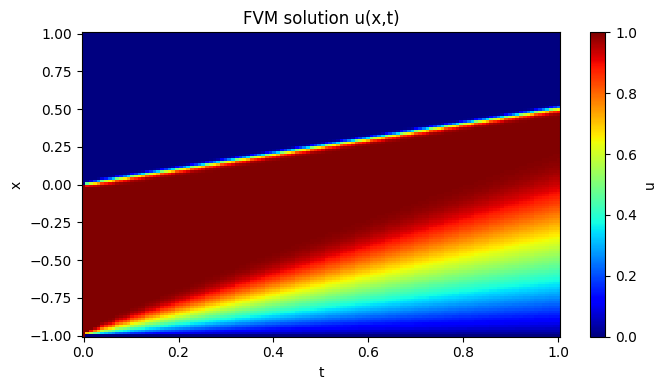

NameError: name 'train_fno_burgers_path' is not defined

In [117]:
def solve_burgers_fvm(nx=256, nt_out=101, x_min=-1.0, x_max=1.0, t_max=4.0,
                      nu=0.01/np.pi, cfl=0.4, noise_std=0.0, seed=42):
    rng = np.random.default_rng(seed)
    x = np.linspace(x_min, x_max, nx)
    dx = x[1] - x[0]

    # Initial condition consistent with the classic Burgers setup
    # Initial condition (Riemann step)
    u = np.where(x > 0.0, 0.0, 1.0)
    #u[0] = 10.0
    #u[-1] = 0.0

    t_out = np.linspace(0.0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        if nu > 0.0:
            dt_diff = 0.5 * dx * dx / nu
        else:
            dt_diff = np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        # Rusanov (local Lax-Friedrichs) flux for convection
        uL = u[:-1]
        uR = u[1:]
        fL = 0.5 * uL * uL
        fR = 0.5 * uR * uR
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5 * (fL + fR) - 0.5 * alpha * (uR - uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = (
                u[1:-1]
                - (dt / dx) * (fhat[1:] - fhat[:-1])
                + (nu * dt / (dx * dx)) * (u[2:] - 2.0 * u[1:-1] + u[:-2])
            )
        else:
            u_new[1:-1] = (
                u[1:-1]
                - (dt / dx) * (fhat[1:] - fhat[:-1])
            )
        u_new[0] = 0.0
        u_new[-1] = 0.0

        u = u_new
        t += dt

        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u
            k += 1

    if noise_std > 0.0:
        u_hist = u_hist + noise_std * rng.standard_normal(u_hist.shape)

    return x, t_out, u_hist


x_fvm, t_fvm, u_fvm = solve_burgers_fvm(nx=128, nt_out=128, noise_std=0.0, nu = 0, t_max = 1.0)
print('FVM grids:', x_fvm.shape, t_fvm.shape, u_fvm.shape)

plt.figure(figsize=(7, 4))
plt.pcolormesh(t_fvm, x_fvm, u_fvm.T, shading='auto', cmap='jet')
plt.xlabel('t')
plt.ylabel('x')
plt.title('FVM solution u(x,t)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()
def burgers_fvm_step_dirichlet(nx=256, nt_out=101, t_max=4.0, nu=0.0, cfl=0.4):
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]

    # Step initial condition (Riemann)
    u = np.where(x > 0.0, 0.0, 1.0)
    t_out = np.linspace(0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        dt_diff = 0.5 * dx**2 / nu if nu > 0 else np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        uL, uR = u[:-1], u[1:]
        fL, fR = 0.5*uL**2, 0.5*uR**2
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5*(fL+fR) - 0.5*alpha*(uR-uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1]) + nu*dt/dx**2*(u[2:]-2*u[1:-1]+u[:-2])
        else:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1])

        # Dirichlet BCs
        u_new[0], u_new[-1] = 0.0, 0.0

        u = u_new
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist
def burgers_fvm_sine_dirichlet(nx=256, nt_out=101, t_max=4.0, nu=0.0, cfl=0.4):
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]

    # Sine initial condition
    u = -np.sin(np.pi * x)
    t_out = np.linspace(0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        dt_diff = 0.5 * dx**2 / nu if nu > 0 else np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        uL, uR = u[:-1], u[1:]
        fL, fR = 0.5*uL**2, 0.5*uR**2
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5*(fL+fR) - 0.5*alpha*(uR-uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1]) + nu*dt/dx**2*(u[2:]-2*u[1:-1]+u[:-2])
        else:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1])

        # Dirichlet BCs
        u_new[0], u_new[-1] = 0.0, 0.0

        u = u_new
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist
fno_model = train_fno_burgers_path('burgers_sine.mat')
plot_fno_vs_truth(fno_model, path='burgers_sine.mat', title_prefix='FNO (sine IC, Dirichlet BC)')

fno_model = train_fno_burgers_path('burgers_step_dirichlet.mat')
plot_fno_vs_truth(fno_model, path='burgers_step_dirichlet.mat', title_prefix='FNO (Step IC, Dirichlet BC)')

fno_model = train_fno_burgers_path('burgers_sine_dirichlet.mat')
plot_fno_vs_truth(fno_model, path='burgers_sine_dirichlet.mat', title_prefix='FNO (Sine IC, Dirichlet BC)')

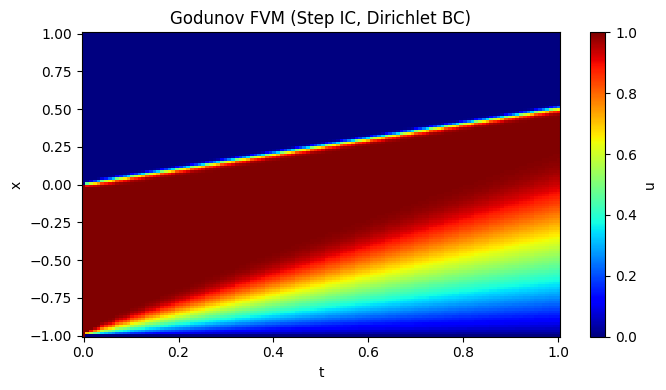

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.pcolormesh(
    t_fvm,
    x_fvm,
    u_fvm.T,      # transpose is important
    shading='auto',
    cmap='jet'
)
plt.xlabel('t')
plt.ylabel('x')
plt.title('Godunov FVM (Step IC, Dirichlet BC)')
plt.colorbar(label='u')
plt.tight_layout()
plt.show()


In [121]:
def plot_fvm_vs_truth(
    path='burgers_shock.mat',
    title_prefix='Godunov FVM'
):
    # Load truth exactly like FNO does
    inp, out, x, t = fno_prepare_burgers_grid(path)

    truth_np = out.squeeze(0).squeeze(0).cpu().numpy()
    X = x.cpu().numpy()
    T = t.cpu().numpy()

    nx = len(X)
    nt = len(T)

    # --- Run your Godunov solver on the SAME grid ---

    pred_np = u_fvm
    pred_np = u_fvm.T
    err_np = np.abs(pred_np - truth_np)

    # Plot 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    plot_heatmaps(
        X,
        T,
        pred_np,
        truth_np,
        err_np,
        title_prefix,
        axes
    )

    plt.show()


In [123]:
plot_fvm_vs_truth(
    path='burgers_shock.mat',
    title_prefix='Godunov FVM'
)


NameError: name 'fno_prepare_burgers_grid' is not defined

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Run the simulation
x_god, t_god, u_god = burgers_fvm_godunov_periodic(
    nx=256, 
    nt_out=100, 
    t_max=1.5, 
    nu=0.0,   # Purely hyperbolic (no physical diffusion)
    cfl=0.4
)

# 2. Visualize the results
plt.figure(figsize=(10, 5))
plt.pcolormesh(t_god, x_god, u_god.T, shading='auto', cmap='jet')
plt.colorbar(label='u(x,t)')
plt.xlabel('Time (t)')
plt.ylabel('Space (x)')
plt.title('Burgers Equation: Godunov Method (Periodic Step)')
plt.show()

NameError: name 'burgers_fvm_godunov_periodic' is not defined

In [127]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

def plot_burgers_mat(path="burgers_shock.mat"):
    data = sio.loadmat(path)

    x = data["x"].squeeze()   
    t = data["t"].squeeze()     
    u = data["usol"]            

    #if u.shape == (len(t), len(x)):
     #   u = u.T
    plt.figure(figsize=(7, 4))
    plt.pcolormesh(t, x, u, shading="auto", cmap="jet")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("Burgers solution u(x,t)")
    plt.colorbar(label="u")
    plt.tight_layout()
    plt.show()



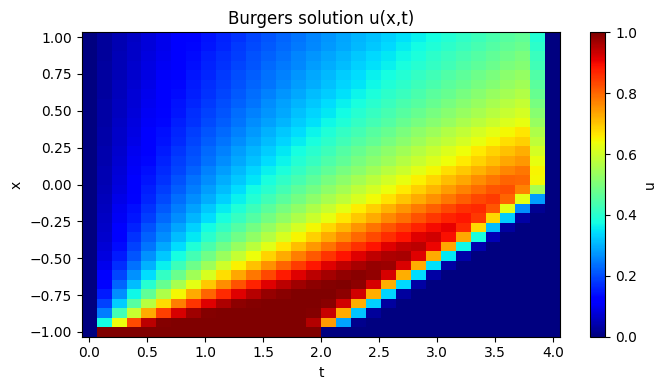

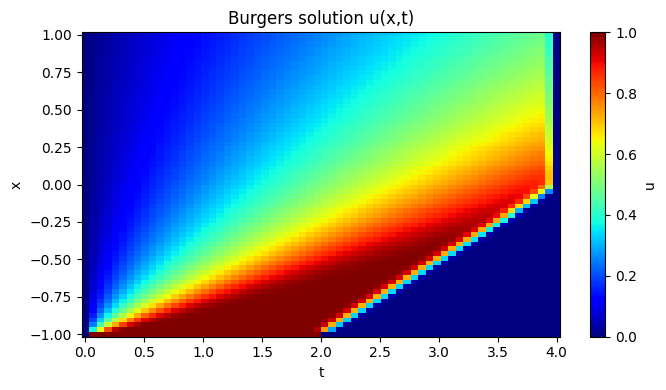

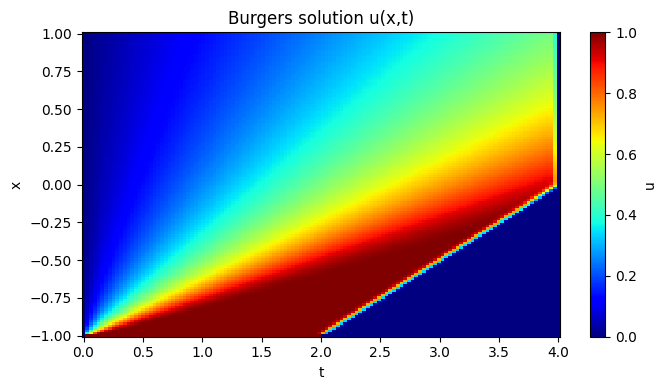

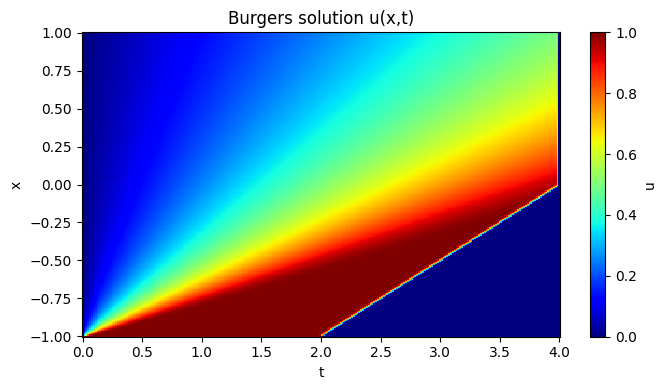

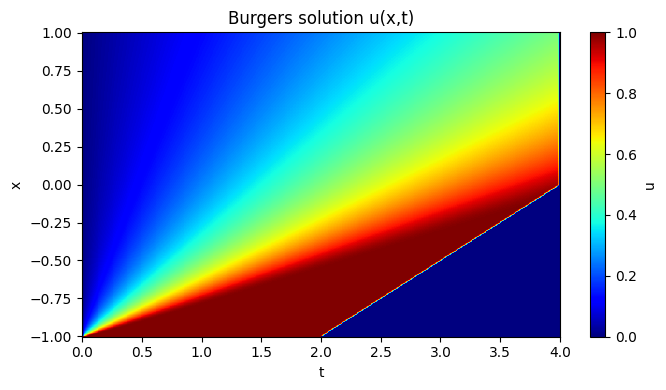

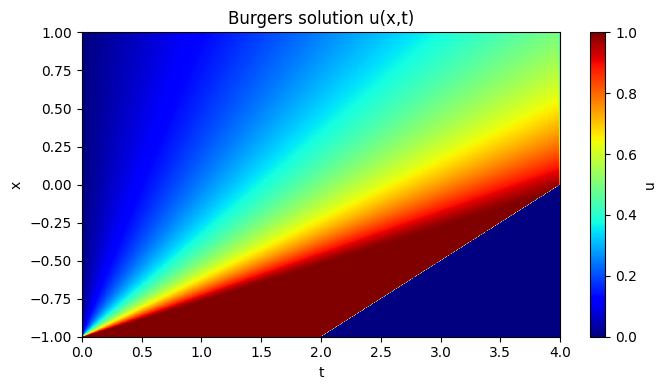

----------------------------------------


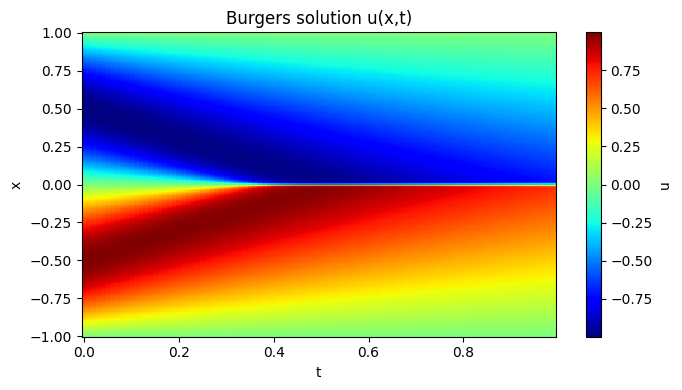

In [129]:


resolution_list = [32,64,128,256,512,1024]
for i in resolution_list:
    plot_burgers_mat(f"burgers_hyp_{i}.mat")
    
print('----------------------------------------')
plot_burgers_mat(f"burgers_shock.mat")


In [130]:
class BurgersPINN(torch.nn.Module):
    def __init__(
        self,
        hidden_layers: int = 4,
        hidden_width: int = 64,
        hard_boundary: bool = False,
        hard_init: bool = False,
        activation='tanh',
    ):
        super().__init__()

        def make_activation(act):
            if isinstance(act, str):
                key = act.lower()
                if key == 'relu':
                    return torch.nn.ReLU()
                if key == 'gelu':
                    return torch.nn.GELU()
                if key == 'tanh':
                    return torch.nn.Tanh()
                raise ValueError(f"Unsupported activation: {act}")
            if isinstance(act, type) and issubclass(act, torch.nn.Module):
                return act()
            if isinstance(act, torch.nn.Module):
                return act.__class__()
            raise TypeError('string or torch.nn only')

        layers = []
        in_features = 2
        for _ in range(hidden_layers):
            layers.append(torch.nn.Linear(in_features, hidden_width))
            layers.append(make_activation(activation))
            in_features = hidden_width
        layers.append(torch.nn.Linear(in_features, 1))
        self.model = torch.nn.Sequential(*layers)
        self.hard_boundary = hard_boundary
        self.hard_init = hard_init

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        inputs = torch.cat([x, t], dim=1)
        out = self.model(inputs)
        if self.hard_boundary:  # hard boundary on both the initial and boundary conditions, CHANGE ACCORDING TO PINN DETAILS
            xi = (x - X_MIN) / (X_MAX - X_MIN)
            out = (xi * (1.0 - xi) * out)
        if self.hard_init:
            out = torch.tanh(x) + t * out
        return out

def burgers_residual(model: BurgersPINN, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    ones = torch.ones_like(u)
    u_t = torch.autograd.grad(u, t, ones, create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, ones, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, ones, create_graph=True)[0]
    v = 0.01 / torch.pi
    return u_t + u * u_x - v * u_xx


In [131]:
def train_pinn(layers, width, steps, lr, interior_samples, boundary_samples, initial_samples, hard_boundary, hard_init, activation):
    model = BurgersPINN(hidden_layers=layers, hidden_width=width, hard_boundary=hard_boundary, hard_init = hard_init, activation=activation).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for step in range(1, steps + 1):
        optimizer.zero_grad(set_to_none=True)

        x_i, t_i = sample_interior(interior_samples)
        residual = burgers_residual(model, x_i, t_i)
        loss_residual = residual.pow(2).mean()

        loss_boundary = torch.tensor(0.0, device=device)
        
        loss_initial = torch.tensor(0.0, device=device)
        if not hard_boundary:
            (x_b0, t_b0), (x_b1, t_b1) = sample_boundary(boundary_samples)
            u_b0 = model(x_b0, t_b0)
            u_b1 = model(x_b1, t_b1)
            loss_boundary = u_b0.pow(2).mean() + u_b1.pow(2).mean()

        if not hard_init:
            
            x_init, t_init = sample_initial(initial_samples)
            u_init = model(x_init, t_init)
            target_init = exact_solution(x_init, t_init)
            loss_initial = (u_init - target_init).pow(2).mean()
        loss = loss_residual + loss_initial + loss_boundary
        loss.backward()
        optimizer.step()

        history.append({
            'step': step,
            'loss': float(loss.item()),
            'residual': float(loss_residual.item()),
            'initial': float(loss_initial.item()),
            'boundary': float(loss_boundary.item()),
        })

        if step % 500 == 0 or step == 1:
            tag = 'hard' if hard_boundary else 'soft'
            msg = f"[{tag}] step {step:4d} | total={loss.item():.3e} | residual={loss_residual.item():.3e} | init={loss_initial.item():.3e}"
            if not hard_boundary:
                msg += f" | bc={loss_boundary.item():.3e}"
            print(msg)

    return model


In [135]:
@torch.no_grad()
def evaluate_model(model: BurgersPINN, num_x: int = 100, num_t: int = 100):
    x = torch.linspace(X_MIN, X_MAX, num_x, device=device)
    t = torch.linspace(T_MIN, T_MAX, num_t, device=device)
    X, T = torch.meshgrid(x, t, indexing='ij')

    Xf = X.reshape(-1, 1)
    Tf = T.reshape(-1, 1)

    U = model(Xf, Tf).reshape(num_x, num_t)
    U_exact = exact_solution(Xf, Tf).reshape(num_x, num_t)

    error = (U - U_exact).abs()
    return X.cpu().numpy(), T.cpu().numpy(), U.cpu().numpy(), U_exact.cpu().numpy(), error.cpu().numpy()



In [137]:
def plot_heatmaps(X, T, prediction, truth, error, title_prefix, axes_row):
    im0 = axes_row[0].pcolormesh(T, X, prediction, shading='auto', cmap='jet')
    axes_row[0].set_title(f'{title_prefix} prediction')
    axes_row[0].set_xlabel('t')
    axes_row[0].set_ylabel('x')
    plt.colorbar(im0, ax=axes_row[0])

    im1 = axes_row[1].pcolormesh(T, X, truth, shading='auto', cmap='jet')
    axes_row[1].set_title('analytic solution')
    axes_row[1].set_xlabel('t')
    axes_row[1].set_ylabel('x')
    plt.colorbar(im1, ax=axes_row[1])

    im2 = axes_row[2].pcolormesh(T, X, error, shading='auto', cmap='magma')
    axes_row[2].set_title('absolute error')
    axes_row[2].set_xlabel('t')
    axes_row[2].set_ylabel('x')
    plt.colorbar(im2, ax=axes_row[2])



In [139]:
def grid_search_architectures(
    layers_list=(3, 4),
    width_list=(32, 64),
    activation_list=('relu', 'gelu', 'tanh'),
    lr=1e-3,
    steps=1500,
    interior_samples=1024,
    boundary_samples=256,
    initial_samples=256,
    hard_boundary=True,
    hard_init=True,
    seed=42,
    eval_num_x=100,
    eval_num_t=100,
    max_runs=None,
    print_each=True,
    top_n=5,
    return_df=False,
):  # noqa: D401
    """Grid search over layer count, width, and activation."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    def train_once(cfg):
        model = BurgersPINN(
            hidden_layers=cfg['hidden_layers'],
            hidden_width=cfg['hidden_width'],
            activation=cfg['activation'],
            hard_boundary=cfg['hard_boundary'],
            hard_init=cfg['hard_init'],
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])

        for _ in range(cfg['steps']):
            optimizer.zero_grad(set_to_none=True)
            x_i, t_i = sample_interior(cfg['interior_samples'])
            residual = burgers_residual(model, x_i, t_i)
            loss_residual = residual.pow(2).mean()

            loss_boundary = torch.tensor(0.0, device=device)
            if not cfg['hard_boundary']:
                (x_b0, t_b0), (x_b1, t_b1) = sample_boundary(cfg['boundary_samples'])
                u_b0 = model(x_b0, t_b0)
                u_b1 = model(x_b1, t_b1)
                loss_boundary = u_b0.pow(2).mean() + u_b1.pow(2).mean()

            loss_initial = torch.tensor(0.0, device=device)
            if not cfg['hard_init']:
                x_init, t_init = sample_initial(cfg['initial_samples'])
                u_init = model(x_init, t_init)
                target_init = exact_solution(x_init, t_init)
                loss_initial = (u_init - target_init).pow(2).mean()

            loss = loss_residual + loss_initial + loss_boundary
            loss.backward()
            optimizer.step()

        return model, float(loss.item())

    configs = []
    for layers in layers_list:
        for width in width_list:
            for act in activation_list:
                configs.append({
                    'hidden_layers': layers,
                    'hidden_width': width,
                    'activation': act,
                    'lr': lr,
                    'steps': steps,
                    'interior_samples': interior_samples,
                    'boundary_samples': boundary_samples,
                    'initial_samples': initial_samples,
                    'hard_boundary': hard_boundary,
                    'hard_init': hard_init,
                })

    if max_runs is not None:
        configs = configs[:max_runs]

    results = []
    best = None

    for idx, cfg in enumerate(configs, start=1):
        model, loss = train_once(cfg)
        X, T, U, U_exact, err = evaluate_model(model, num_x=eval_num_x, num_t=eval_num_t)
        err_t = torch.tensor(err)
        mse = float((err_t ** 2).mean().item())

        row = {**cfg}
        row.update({'loss': loss, 'mse': mse})
        results.append(row)

        if best is None or mse < best['mse']:
            best = {
                'cfg': cfg,
                'mse': mse,
                'loss': loss,
                'model': model,
                'eval': (X, T, U, U_exact, err),
            }

        if print_each:
            print(
                f"[{idx}/{len(configs)}] layers={cfg['hidden_layers']} width={cfg['hidden_width']} "
                f"act={cfg['activation']} | loss={loss:.3e} | mse={mse:.3e}"
            )

    df = pd.DataFrame(results)
    if df.empty:
        print('No runs executed.')
        return (df, best) if return_df else best

    cols = [
        'hidden_layers', 'hidden_width', 'activation',
        'lr', 'steps', 'interior_samples', 'boundary_samples', 'initial_samples',
        'hard_boundary', 'hard_init', 'loss', 'mse'
    ]
    df_display = df[cols].copy().round(3)

    if top_n and top_n > 0:
        print('\nTop runs by MSE:')
        print(df_display.sort_values('mse').head(top_n).to_string(index=False))

    return (df, best) if return_df else best


In [142]:
def sweep_hyperparams(
    lr_list=(1e-3,),
    steps_list=(1500, 2500,),
    interior_list=(512, 256 ,128),
    boundary_list=(512, 256 ,128),
    initial_list=(512, 256 ,128),
    hidden_layers_list=(4,),
    hidden_width_list=(64,),
    hard_boundary_list=(True,),
    seed=42,
    eval_num_x=100,
    eval_num_t=100,
    max_runs=None,
):
    """Grid sweep over hyperparameters and print summary tables."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    def train_once(cfg):
        model = BurgersPINN(
            hidden_layers=cfg['hidden_layers'],
            hidden_width=cfg['hidden_width'],
            hard_boundary=cfg['hard_boundary'],
            hard_init=cfg['hard_init'],
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])

        for _ in range(cfg['steps']):
            optimizer.zero_grad(set_to_none=True)
            x_i, t_i = sample_interior(cfg['interior_samples'])
            residual = burgers_residual(model, x_i, t_i)
            loss_residual = residual.pow(2).mean()

            loss_boundary = torch.tensor(0.0, device=device)
            if not cfg['hard_boundary']:
                (x_b0, t_b0), (x_b1, t_b1) = sample_boundary(cfg['boundary_samples'])
                u_b0 = model(x_b0, t_b0)
                u_b1 = model(x_b1, t_b1)
                loss_boundary = u_b0.pow(2).mean() + u_b1.pow(2).mean()

            loss_initial = torch.tensor(0.0, device=device)
            if not cfg['hard_init']:
                x_init, t_init = sample_initial(cfg['initial_samples'])
                u_init = model(x_init, t_init)
                target_init = exact_solution(x_init, t_init)
                loss_initial = (u_init - target_init).pow(2).mean()

            loss = loss_residual + loss_initial + loss_boundary
            loss.backward()
            optimizer.step()

        return model, float(loss.item())

    configs = []
    for combo in itertools.product(
        lr_list, steps_list, interior_list, boundary_list, initial_list,
        hidden_layers_list, hidden_width_list, hard_boundary_list
    ):
        cfg = {
            'lr': combo[0],
            'steps': combo[1],
            'interior_samples': combo[2],
            'boundary_samples': combo[3],
            'initial_samples': combo[4],
            'hidden_layers': combo[5],
            'hidden_width': combo[6],
            'hard_boundary': combo[7],
            'hard_init': combo[7],
        }
        configs.append(cfg)

    if max_runs is not None:
        configs = configs[:max_runs]

    results = []
    best_soft = None
    best_hard = None

    for idx, cfg in enumerate(configs, start=1):
        start = time.time()
        model, loss = train_once(cfg)
        X, T, U, U_exact, err = evaluate_model(model, num_x=eval_num_x, num_t=eval_num_t)
        err_t = torch.tensor(err)
        mse = float((err_t ** 2).mean().item())
        elapsed = time.time() - start

        row = {**cfg}
        row.update({
            'loss': loss,
            'mse': mse,
            'seconds': elapsed,
        })
        results.append(row)

        best = best_hard if cfg['hard_boundary'] else best_soft
        if best is None or mse < best['mse']:
            snapshot = {
                'cfg': cfg,
                'mse': mse,
                'loss': loss,
                'model': model,
                'eval': (X, T, U, U_exact, err),
            }
            if cfg['hard_boundary']:
                best_hard = snapshot
            else:
                best_soft = snapshot

        print(f"[{idx}/{len(configs)}] lr={cfg['lr']}, steps={cfg['steps']}, hard={cfg['hard_boundary']} | loss={loss:.3e} | mse={mse:.3e}")

    df = pd.DataFrame(results)
    if df.empty:
        print('No runs executed.')
        return df

    cols = [
        'lr', 'steps', 'interior_samples', 'boundary_samples', 'initial_samples',
        'hidden_layers', 'hidden_width', 'hard_boundary', 'hard_init', 'loss', 'mse', 'seconds'
    ]
    df_display = df[cols].copy()
    df_display = df_display.round(2)

    print('\nTop runs by MSE:')
    print(df_display.sort_values('mse').head(10).to_string(index=False))

    print('\nMean metrics by hyperparameter:')
    for col in ['lr', 'steps', 'interior_samples', 'boundary_samples', 'initial_samples', 'hidden_layers', 'hidden_width', 'hard_boundary']:
        summary = df.groupby(col)[['loss', 'mse']].mean().round(2).sort_values('mse')
        print(f"\n[{col}]")
        print(summary.to_string())

    if best_soft is not None and best_hard is not None:
        (Xs, Ts, soft_pred, soft_true, soft_err) = best_soft['eval']
        (Xh, Th, hard_pred, hard_true, hard_err) = best_hard['eval']
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
        plot_heatmaps(Xs, Ts, soft_pred, soft_true, soft_err, 'Soft PINN (best)', axes[0])
        plot_heatmaps(Xh, Th, hard_pred, hard_true, hard_err, 'Hard PINN (best)', axes[1])
        plt.show()

    return df


In [144]:
best_combo = train_pinn(4,128, 3500, 1e-3, 512, 128, 512, False, False, 'gelu')

[soft] step    1 | total=5.265e-01 | residual=3.623e-06 | init=5.195e-01 | bc=7.003e-03
[soft] step  500 | total=6.157e-02 | residual=4.394e-02 | init=1.720e-02 | bc=4.392e-04
[soft] step 1000 | total=5.488e-02 | residual=4.072e-02 | init=1.401e-02 | bc=1.416e-04
[soft] step 1500 | total=5.906e-02 | residual=4.540e-02 | init=1.350e-02 | bc=1.649e-04
[soft] step 2000 | total=5.265e-02 | residual=4.265e-02 | init=9.414e-03 | bc=5.809e-04
[soft] step 2500 | total=4.362e-02 | residual=3.507e-02 | init=8.164e-03 | bc=3.842e-04
[soft] step 3000 | total=2.583e-02 | residual=1.972e-02 | init=5.295e-03 | bc=8.134e-04
[soft] step 3500 | total=1.527e-02 | residual=9.575e-03 | init=5.569e-03 | bc=1.243e-04


In [172]:
class SpectralConv2d(torch.nn.Module):
    def __init__(self, in_channels, out_channels, modes_x, modes_t):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_x = modes_x
        self.modes_t = modes_t
        scale = 1.0 / (in_channels * out_channels)
        self.weight = torch.nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes_x, modes_t, dtype=torch.cfloat)
        )

    def forward(self, x):
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(
            x.size(0),
            self.out_channels,
            x.size(-2),
            x_ft.size(-1),
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, : self.modes_x, : self.modes_t] = torch.einsum(
            'bixy,ioxy->boxy',
            x_ft[:, :, : self.modes_x, : self.modes_t],
            self.weight,
        )
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class FNO2d(torch.nn.Module):
    def __init__(self, in_channels=2, out_channels=1, width=32, modes_x=16, modes_t=16, layers=4):
        super().__init__()
        self.width = width
        self.lift = torch.nn.Conv2d(in_channels, width, 1)
        self.spectral_layers = torch.nn.ModuleList()
        self.pointwise_layers = torch.nn.ModuleList()
        for _ in range(layers):
            self.spectral_layers.append(SpectralConv2d(width, width, modes_x, modes_t))
            self.pointwise_layers.append(torch.nn.Conv2d(width, width, 1))
        self.proj = torch.nn.Sequential(
            torch.nn.Conv2d(width, width, 1),
            torch.nn.GELU(),
            torch.nn.Conv2d(width, out_channels, 1),
        )

    def forward(self, x):
        x = self.lift(x)
        for spec, pw in zip(self.spectral_layers, self.pointwise_layers):
            x = torch.nn.functional.gelu(spec(x) + pw(x))
        x = self.proj(x)
        return x


def fno_prepare_burgers_grid(path):
    data = sio.loadmat(path)

    x = torch.tensor(data['x'], dtype=torch.float32).squeeze()
    t = torch.tensor(data['t'], dtype=torch.float32).squeeze()
    u = torch.tensor(data['usol'], dtype=torch.float32)

    Nx = x.numel()
    Nt = t.numel()

    # burgers_shock.mat stores u as (Nt, Nx)
    if u.shape == (Nt, Nx):
        u = u.T
    elif u.shape != (Nx, Nt):
        raise ValueError(f"Unexpected usol shape {u.shape}, expected {(Nt, Nx)} or {(Nx, Nt)}")

    # now this is GUARANTEED
    assert u.shape == (Nx, Nt)

    X, T = torch.meshgrid(x, t, indexing='ij')

    inp = torch.stack([X, T], dim=0).unsqueeze(0)   # (1, 2, Nx, Nt)
    out = u.unsqueeze(0).unsqueeze(0)               # (1, 1, Nx, Nt)

    return inp, out, x, t



def fno_predict_points(model, x_pts, t_pts):
    x_flat = x_pts.squeeze(1)
    t_flat = t_pts.squeeze(1)
    xs = torch.unique(x_flat).sort().values
    ts = torch.unique(t_flat).sort().values
    Xg, Tg = torch.meshgrid(xs, ts, indexing='ij')
    inp = torch.stack([Xg, Tg], dim=0).unsqueeze(0)
    pred_grid = model(inp).squeeze(0).squeeze(0) 
    ix = torch.searchsorted(xs, x_flat)
    it = torch.searchsorted(ts, t_flat)
    return pred_grid[ix, it].unsqueeze(1)


def train_fno_burgers(
    modes_x=16,
    modes_t=16,
    width=32,
    layers=4,
    lr=5e-3,
    steps=2000,
    seed=42,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    inp, out, _, _ = fno_prepare_burgers_grid('burgers_hyp.mat')
    inp = inp.to(device)
    out = out.to(device)

    model = FNO2d(
        in_channels=2,
        out_channels=1,
        width=width,
        modes_x=modes_x,
        modes_t=modes_t,
        layers=layers,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(1, steps + 1):
        opt.zero_grad(set_to_none=True)
        pred = model(inp)
        loss = (pred - out).pow(2).mean()
        loss.backward()
        opt.step()
        if step % 500 == 0 or step == 1:
            print(f'[FNO] step {step:4d} | mse={loss.item():.3e}')

    return model



In [173]:
def plot_fno_vs_truth(model, path='burgers_hyp.mat', title_prefix='FNO'):  # heatmaps
    inp, out, x, t = fno_prepare_burgers_grid(path)
    inp = inp.to(device)
    out = out.to(device)

    with torch.no_grad():
        pred = model(inp)

    pred_np = pred.squeeze(0).squeeze(0).cpu().numpy()  
    truth_np = out.squeeze(0).squeeze(0).cpu().numpy()
    err_np = np.abs(pred_np - truth_np)

    X = x.cpu().numpy()
    T = t.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    plot_heatmaps(X, T, pred_np, truth_np, err_np, title_prefix, axes)
    plt.show()



[PINN] step    1 | total=5.511e-01 | res=6.194e-05 | init=5.097e-01 | bc=4.125e-02
[PINN] step  500 | total=5.992e-02 | res=3.287e-02 | init=2.477e-02 | bc=2.275e-03
[PINN] step 1000 | total=5.648e-02 | res=4.095e-02 | init=1.374e-02 | bc=1.796e-03
[PINN] step 1500 | total=5.403e-02 | res=3.732e-02 | init=1.467e-02 | bc=2.044e-03


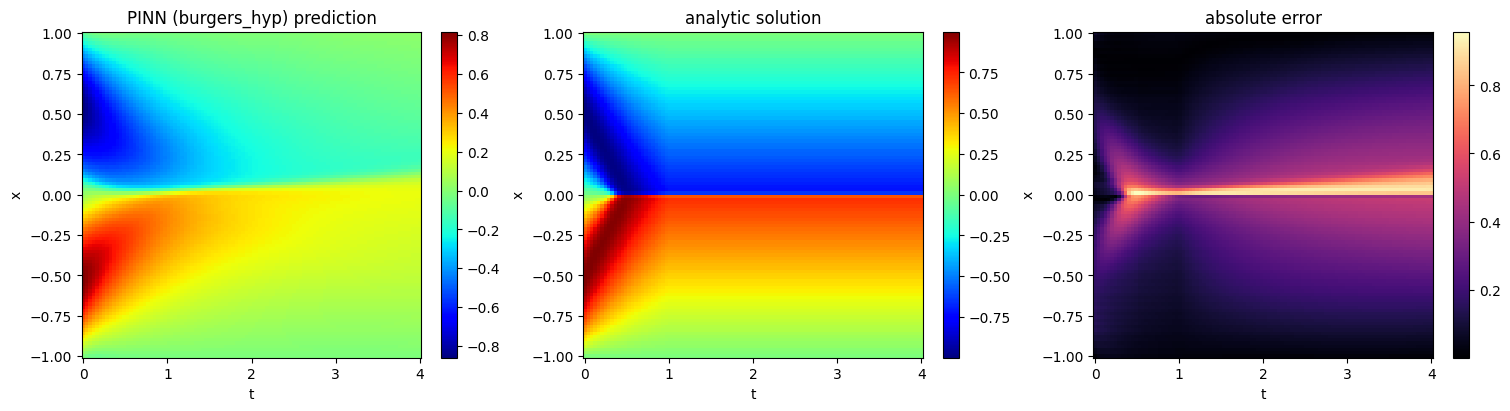

In [174]:

pinn_defaults = dict(
    steps=1500,
    lr=1e-3,
    interior_samples=512,
    boundary_samples=512,
    initial_samples=512,
)

def train_pinn_on_data(cfg):
    model = BurgersPINN(5, 64, hard_boundary=False, hard_init=False).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])

    for step in range(1, cfg['steps'] + 1):
        optimizer.zero_grad(set_to_none=True)

        x_i, t_i = sample_interior(cfg['interior_samples'])
        residual = burgers_residual(model, x_i, t_i)
        loss_residual = residual.pow(2).mean()

        (x_b0, t_b0), (x_b1, t_b1) = sample_boundary(cfg['boundary_samples'])
        u_b0 = model(x_b0, t_b0)
        u_b1 = model(x_b1, t_b1)
        target_b0 = exact_solution(x_b0, t_b0)
        target_b1 = exact_solution(x_b1, t_b1)
        loss_boundary = (u_b0 - target_b0).pow(2).mean() + (u_b1 - target_b1).pow(2).mean()

        x_init, t_init = sample_initial(cfg['initial_samples'])
        u_init = model(x_init, t_init)
        target_init = exact_solution(x_init, t_init)
        loss_initial = (u_init - target_init).pow(2).mean()

        loss = loss_residual + loss_initial + loss_boundary
        loss.backward()
        optimizer.step()

        if step % 500 == 0 or step == 1:
            print(
                f"[PINN] step {step:4d} | total={loss.item():.3e} | "
                f"res={loss_residual.item():.3e} | init={loss_initial.item():.3e} | "
                f"bc={loss_boundary.item():.3e}"
            )

    return model

pinn_model = train_pinn_on_data(pinn_defaults)
X, T, U, U_exact, err = evaluate_model(pinn_model)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
plot_heatmaps(X, T, U, U_exact, err, 'PINN (burgers_hyp)', axes)
plt.show()

# FNO training on burgers_hyp.mat with default params

def train_fno_burgers_path(
    path='burgers_shock.mat',
    modes_x=16,
    modes_t=16,
    width=32,
    layers=4,
    lr=5e-3,
    steps=2000,
    seed=42,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    inp, out, _, _ = fno_prepare_burgers_grid(path)
    inp = inp.to(device)
    out = out.to(device)

    model = FNO2d(
        in_channels=2,
        out_channels=1,
        width=width,
        modes_x=modes_x,
        modes_t=modes_t,
        layers=layers,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(1, steps + 1):
        opt.zero_grad(set_to_none=True)
        pred = model(inp)
        loss = (pred - out).pow(2).mean()
        loss.backward()
        opt.step()
        if step % 500 == 0 or step == 1:
            print(f"[FNO] step {step:4d} | mse={loss.item():.3e}")

    return model

resolution_list = [32,64,128,256,512,1024]
#for i in resolution_list:
#    fno_model = train_fno_burgers_path(f'burgers_hyp_{i}.mat')
 #   plot_fno_vs_truth(fno_model, path='burgers_hyp.mat', title_prefix=f'FNO (burgers_hyp_{i})')



In [175]:
#fno_model = train_fno_burgers_path(
 #   path='burgers_shock.mat',
  #  steps=2000
#)

In [176]:
def burgers_fvm_step_dirichlet(nx=256, nt_out=101, t_max=4.0, nu=0.0, cfl=0.4):
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]

    # Step initial condition (Riemann)
    u = np.where(x > 0.0, 0.0, 1.0)
    t_out = np.linspace(0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        dt_diff = 0.5 * dx**2 / nu if nu > 0 else np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        uL, uR = u[:-1], u[1:]
        fL, fR = 0.5*uL**2, 0.5*uR**2
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5*(fL+fR) - 0.5*alpha*(uR-uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1]) + nu*dt/dx**2*(u[2:]-2*u[1:-1]+u[:-2])
        else:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1])

        # Dirichlet BCs
        u_new[0], u_new[-1] = 0.0, 0.0

        u = u_new
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist


In [151]:
def burgers_fvm_sine_dirichlet(nx=256, nt_out=101, t_max=4.0, nu=0.0, cfl=0.4):
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]

    # Sine initial condition
    u = -np.sin(np.pi * x)
    t_out = np.linspace(0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        dt_diff = 0.5 * dx**2 / nu if nu > 0 else np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        uL, uR = u[:-1], u[1:]
        fL, fR = 0.5*uL**2, 0.5*uR**2
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5*(fL+fR) - 0.5*alpha*(uR-uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1]) + nu*dt/dx**2*(u[2:]-2*u[1:-1]+u[:-2])
        else:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1])

        # Dirichlet BCs
        u_new[0], u_new[-1] = 0.0, 0.0

        u = u_new
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist


In [152]:
def burgers_fvm_step_periodic(nx=256, nt_out=101, t_max=4.0, nu=0.0, cfl=0.4):
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]

    # Step IC
    u = np.where(x > 0.0, 0.0, 1.0)
    t_out = np.linspace(0, t_max, nt_out)
    u_hist = np.zeros((nt_out, nx), dtype=np.float32)
    u_hist[0] = u.copy()

    t = 0.0
    k = 1
    while k < nt_out:
        umax = max(1e-6, np.max(np.abs(u)))
        dt_adv = cfl * dx / umax
        dt_diff = 0.5 * dx**2 / nu if nu > 0 else np.inf
        dt = min(dt_adv, dt_diff, t_max - t)

        uL, uR = u[:-1], u[1:]
        fL, fR = 0.5*uL**2, 0.5*uR**2
        alpha = np.maximum(np.abs(uL), np.abs(uR))
        fhat = 0.5*(fL+fR) - 0.5*alpha*(uR-uL)

        u_new = u.copy()
        if nu > 0.0:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1]) + nu*dt/dx**2*(u[2:]-2*u[1:-1]+u[:-2])
        else:
            u_new[1:-1] = u[1:-1] - dt/dx*(fhat[1:]-fhat[:-1])

        # Periodic BCs
        u_new[0] = u_new[-2]
        u_new[-1] = u_new[1]

        u = u_new
        t += dt
        while k < nt_out and t >= t_out[k] - 1e-12:
            u_hist[k] = u.copy()
            k += 1

    return x, t_out, u_hist


In [156]:
import scipy.io

# Step IC, Dirichlet BC
# -----------------------------
x, t, u = burgers_fvm_step_dirichlet(nx=128, nt_out=128, t_max=2.0)
scipy.io.savemat('burgers_step_dirichlet.mat', {'x': x, 't': t, 'usol': u}) 
# x - spacial grid, t - time grid , usol - the full solution of Burgers’ equation on that grid

# -----------------------------
# Sine IC, Dirichlet BC
# -----------------------------
x, t, u = burgers_fvm_sine_dirichlet(nx=128, nt_out=128, t_max=2.0)
scipy.io.savemat('burgers_sine_dirichlet.mat', {'x': x, 't': t, 'usol': u})

# -----------------------------
# Step IC, Periodic BC
# -----------------------------
x, t, u = burgers_fvm_step_periodic(nx=128, nt_out=128, t_max=2.0)
scipy.io.savemat('burgers_step_periodic.mat', {'x': x, 't': t, 'usol': u})


[FNO] step    1 | mse=2.653e-01
[FNO] step  500 | mse=1.727e-06
[FNO] step 1000 | mse=1.013e-06
[FNO] step 1500 | mse=2.703e-06
[FNO] step 2000 | mse=6.721e-07


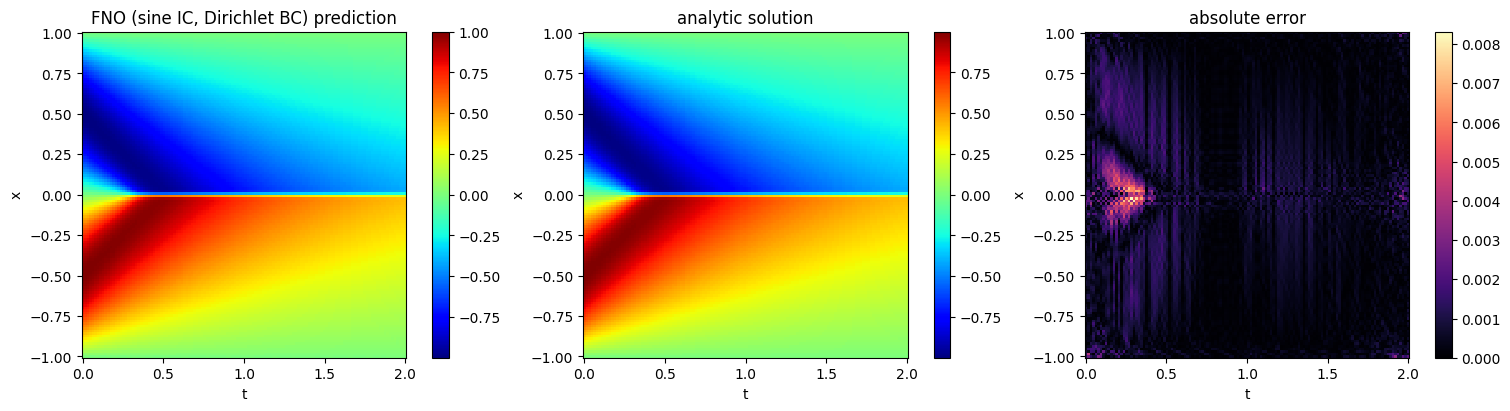

[FNO] step    1 | mse=2.634e-01
[FNO] step  500 | mse=8.911e-06
[FNO] step 1000 | mse=4.553e-06
[FNO] step 1500 | mse=3.052e-06
[FNO] step 2000 | mse=1.039e-06


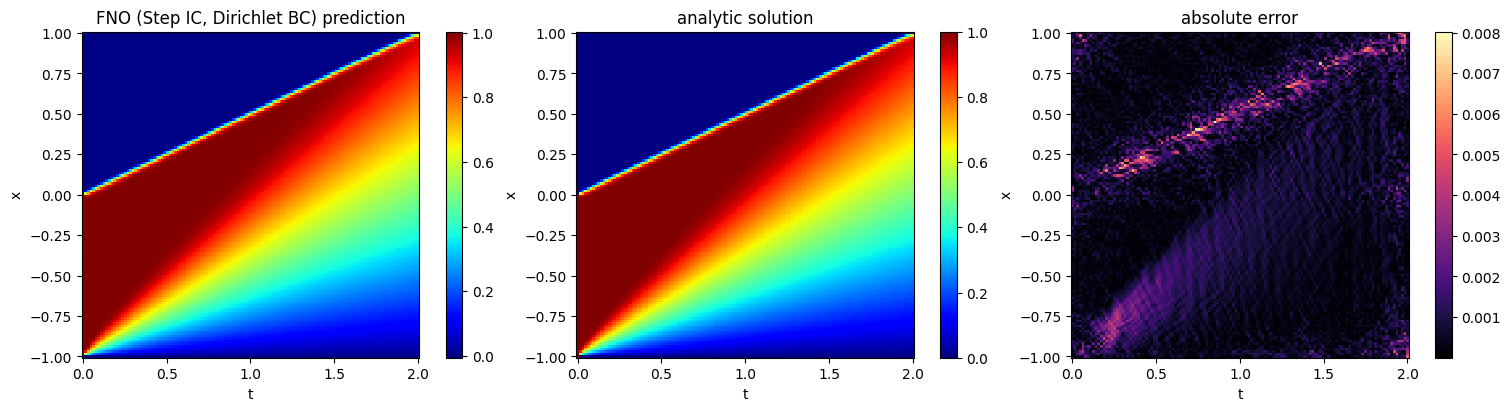

[FNO] step    1 | mse=2.653e-01
[FNO] step  500 | mse=1.727e-06
[FNO] step 1000 | mse=1.013e-06
[FNO] step 1500 | mse=2.703e-06
[FNO] step 2000 | mse=6.721e-07


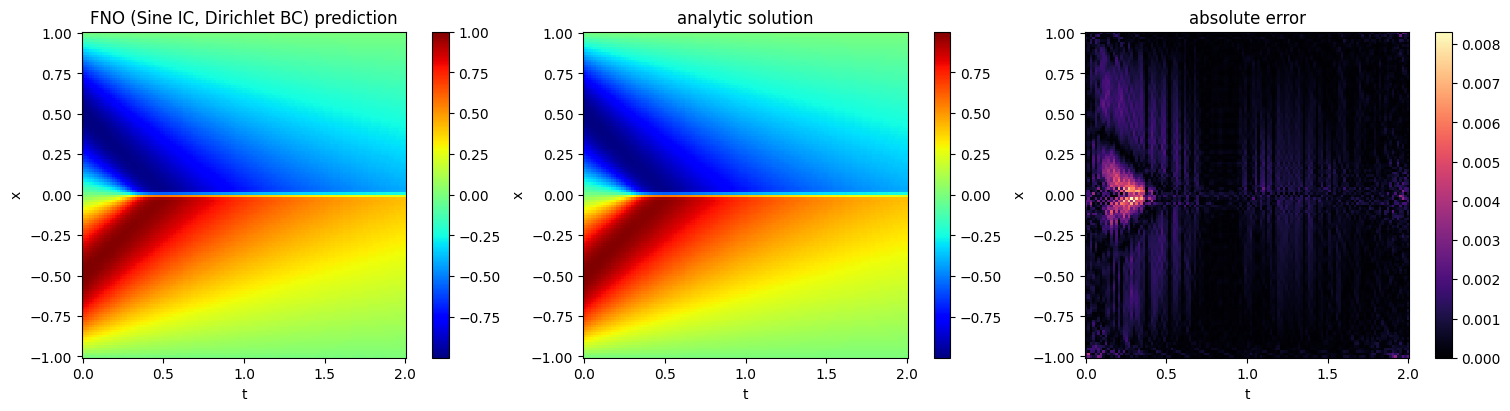

[FNO] step    1 | mse=2.637e-01
[FNO] step  500 | mse=9.584e-06
[FNO] step 1000 | mse=1.726e-05
[FNO] step 1500 | mse=2.231e-06
[FNO] step 2000 | mse=1.054e-06


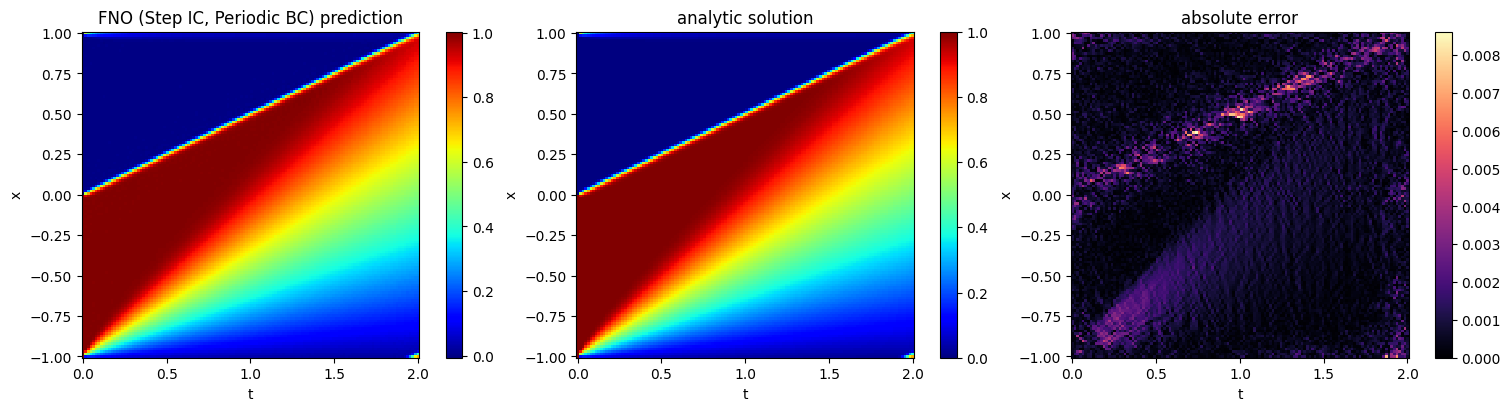

In [171]:
fno_model = train_fno_burgers_path('burgers_sine.mat')
plot_fno_vs_truth(fno_model, path='burgers_sine.mat', title_prefix='FNO (sine IC, Dirichlet BC)')

fno_model = train_fno_burgers_path('burgers_step_dirichlet.mat')
plot_fno_vs_truth(fno_model, path='burgers_step_dirichlet.mat', title_prefix='FNO (Step IC, Dirichlet BC)')

fno_model = train_fno_burgers_path('burgers_sine_dirichlet.mat')
plot_fno_vs_truth(fno_model, path='burgers_sine_dirichlet.mat', title_prefix='FNO (Sine IC, Dirichlet BC)')

fno_model = train_fno_burgers_path('burgers_step_periodic.mat')
plot_fno_vs_truth(fno_model, path='burgers_step_periodic.mat', title_prefix='FNO (Step IC, Periodic BC)')

[FNO] step    1 | mse=2.637e-01
[FNO] step  500 | mse=9.584e-06
[FNO] step 1000 | mse=1.726e-05
[FNO] step 1500 | mse=2.231e-06
[FNO] step 2000 | mse=1.054e-06


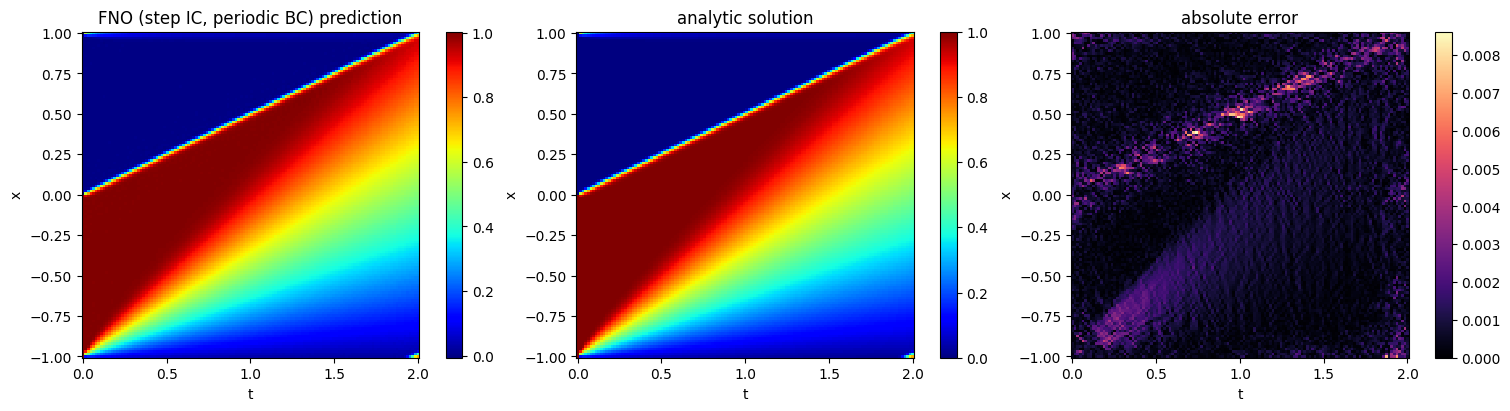

In [160]:
fno_model = train_fno_burgers_path('burgers_step_periodic.mat')
plot_fno_vs_truth(fno_model, path='burgers_step_periodic.mat', title_prefix='FNO (step IC, periodic BC)')


[FNO] step    1 | mse=4.039e-01
[FNO] step  500 | mse=3.790e-06
[FNO] step 1000 | mse=4.644e-06
[FNO] step 1500 | mse=1.162e-07
[FNO] step 2000 | mse=1.029e-07


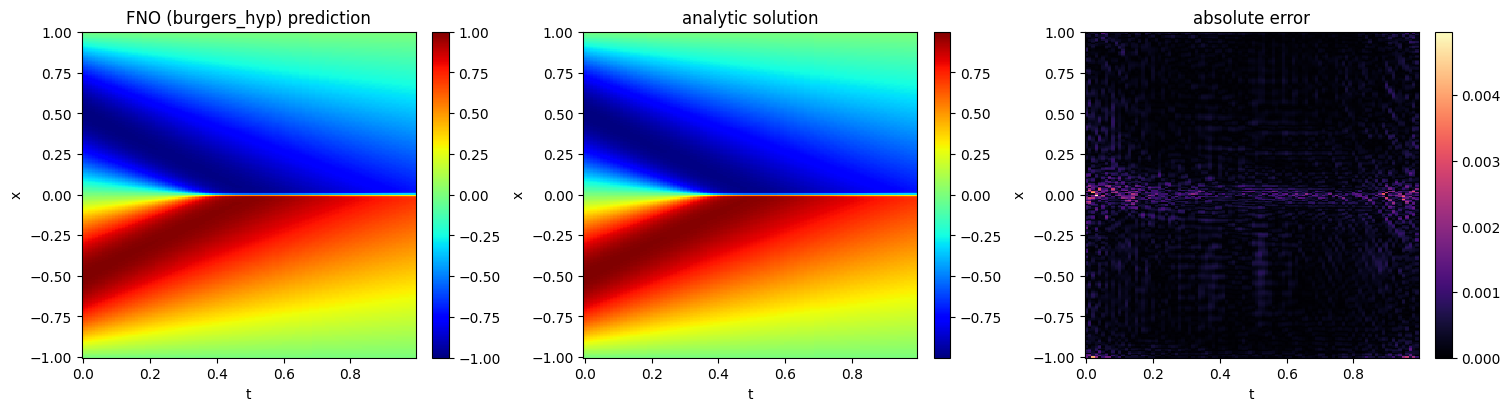

In [164]:

fno_model = train_fno_burgers_path(f'burgers_shock.mat')
plot_fno_vs_truth(fno_model, path='burgers_shock.mat', title_prefix=f'FNO (burgers_hyp)')

[FNO] step    1 | mse=1.445e-01
[FNO] step  500 | mse=3.705e-09
[FNO] step 1000 | mse=6.729e-06
[FNO] step 1500 | mse=1.630e-06
[FNO] step 2000 | mse=1.615e-08


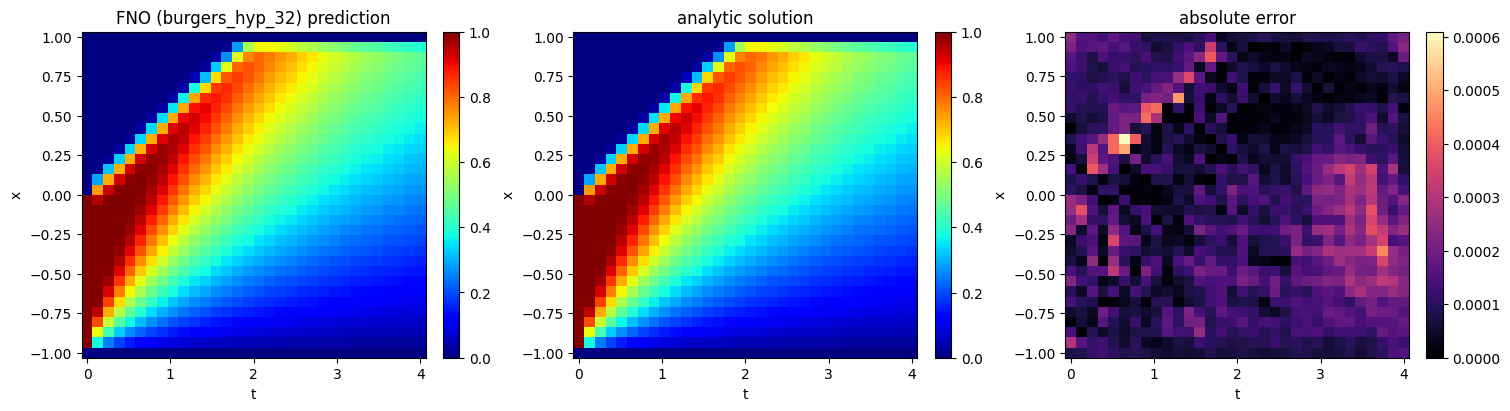

[FNO] step    1 | mse=1.604e-01
[FNO] step  500 | mse=4.649e-05
[FNO] step 1000 | mse=3.082e-07
[FNO] step 1500 | mse=1.158e-07
[FNO] step 2000 | mse=9.296e-07


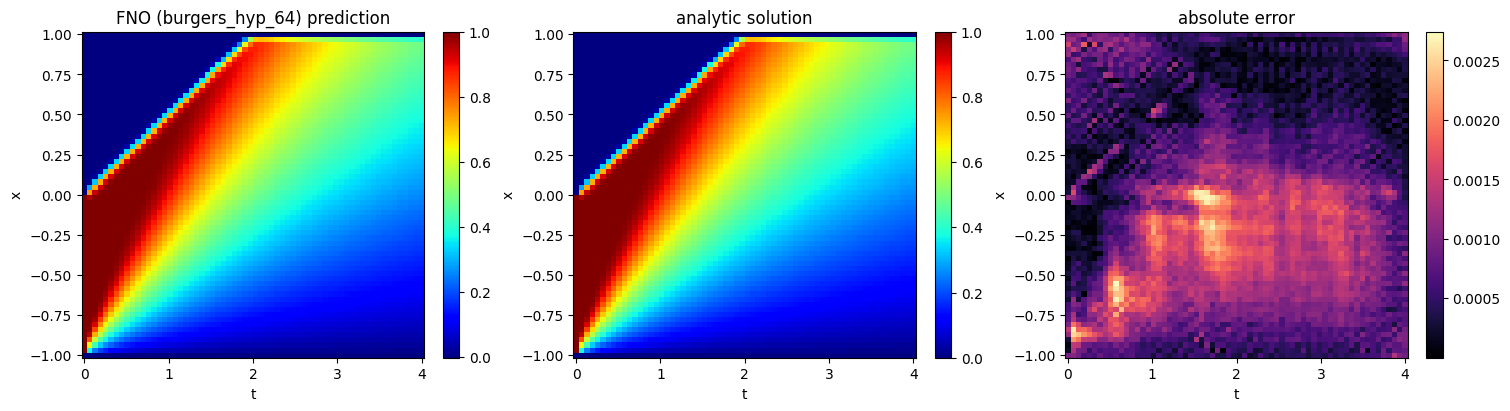

[FNO] step    1 | mse=1.694e-01
[FNO] step  500 | mse=4.228e-04
[FNO] step 1000 | mse=2.367e-05
[FNO] step 1500 | mse=3.096e-05
[FNO] step 2000 | mse=1.671e-05


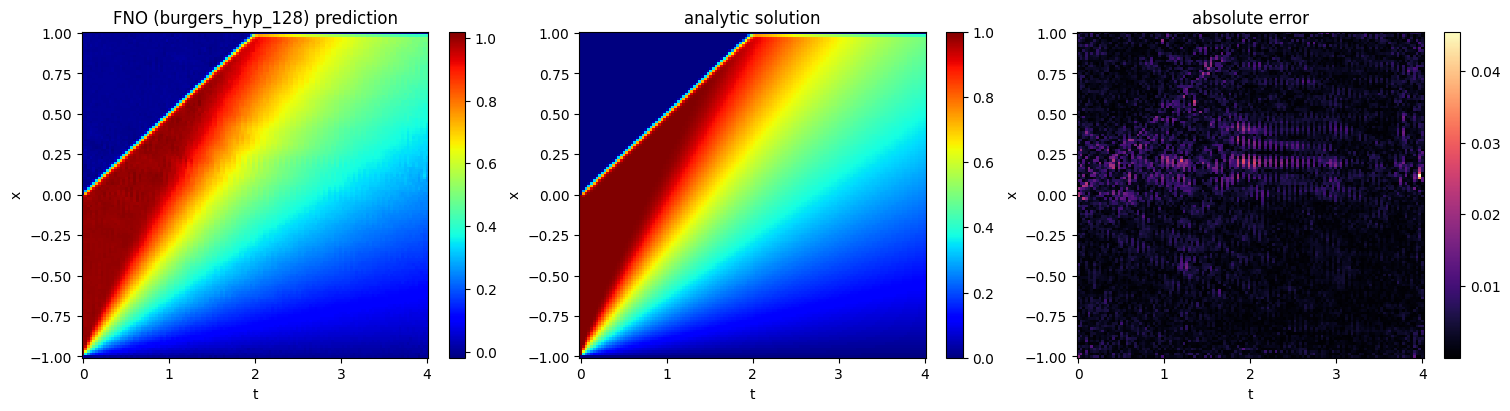

[FNO] step    1 | mse=1.744e-01
[FNO] step  500 | mse=5.585e-04
[FNO] step 1000 | mse=8.623e-05
[FNO] step 1500 | mse=4.630e-05
[FNO] step 2000 | mse=3.911e-05


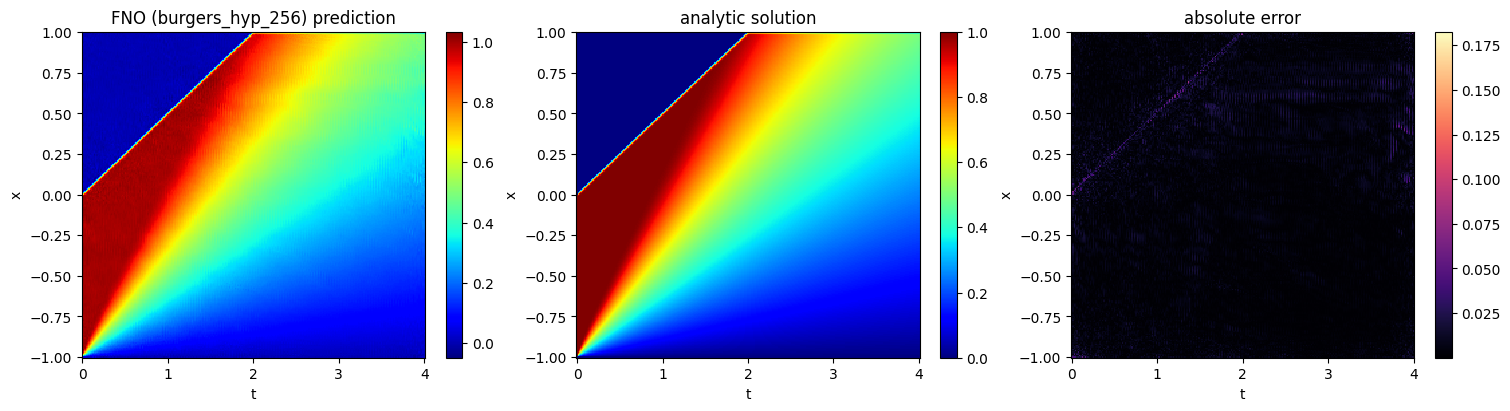

[FNO] step    1 | mse=1.772e-01
[FNO] step  500 | mse=3.242e-04
[FNO] step 1000 | mse=6.286e-06
[FNO] step 1500 | mse=1.145e-05
[FNO] step 2000 | mse=3.712e-06


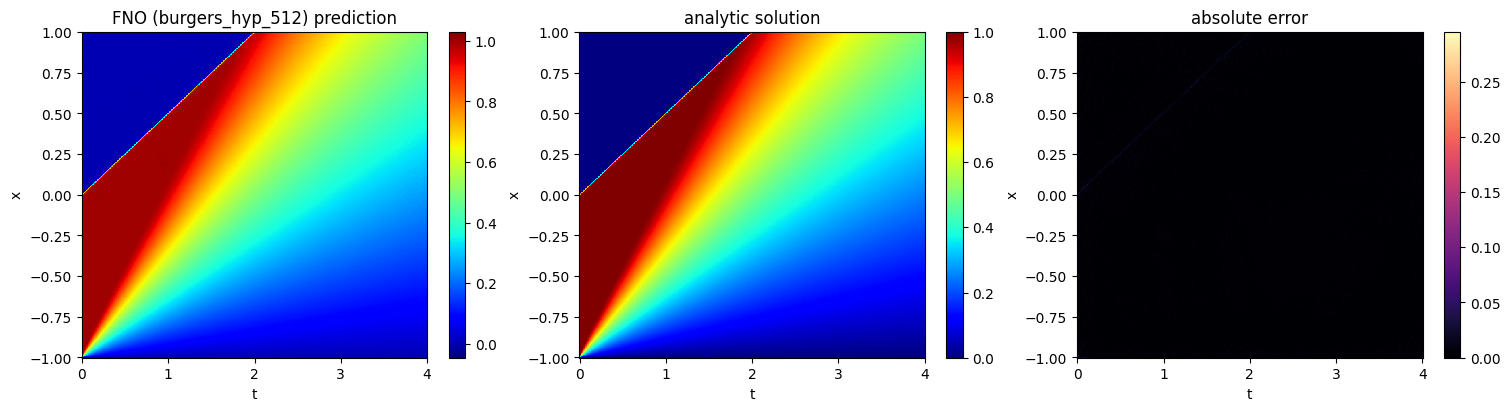

[FNO] step    1 | mse=1.786e-01
[FNO] step  500 | mse=3.160e-04
[FNO] step 1000 | mse=1.427e-04
[FNO] step 1500 | mse=1.175e-04
[FNO] step 2000 | mse=1.490e-04


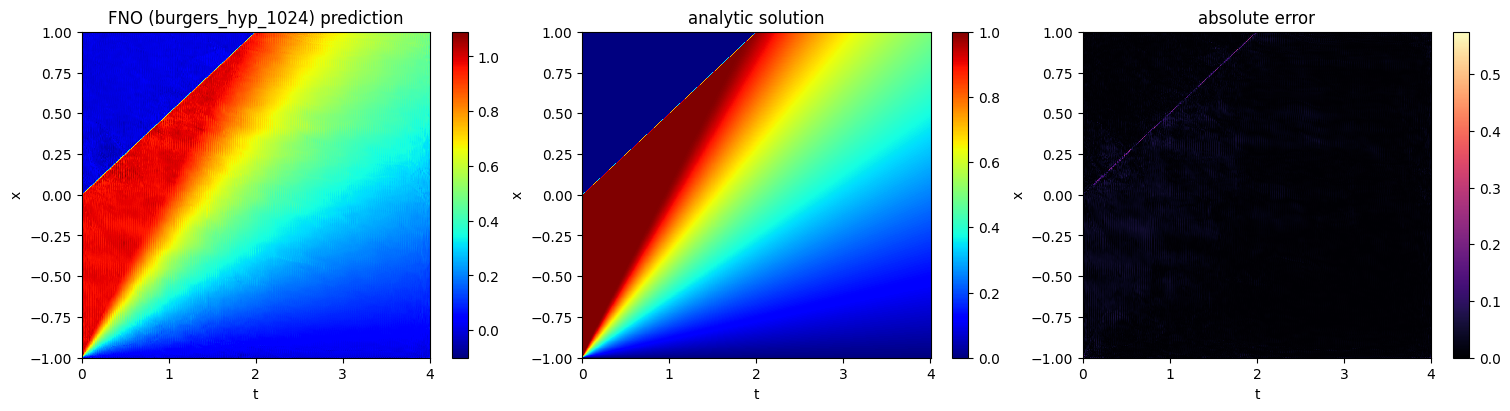

In [ ]:

resolution_list = [32,64,128,256,512,1024]
for i in resolution_list:
    fno_model = train_fno_burgers_path(f'burgers_hyp_{i}.mat')
    plot_fno_vs_truth(fno_model, path=f'burgers_hyp_{i}.mat', title_prefix=f'FNO (burgers_hyp_{i})')

[FNO] step    1 | mse=1.772e-01
[FNO] step  500 | mse=3.242e-04
[FNO] step 1000 | mse=6.286e-06
[FNO] step 1500 | mse=1.145e-05
[FNO] step 2000 | mse=3.712e-06


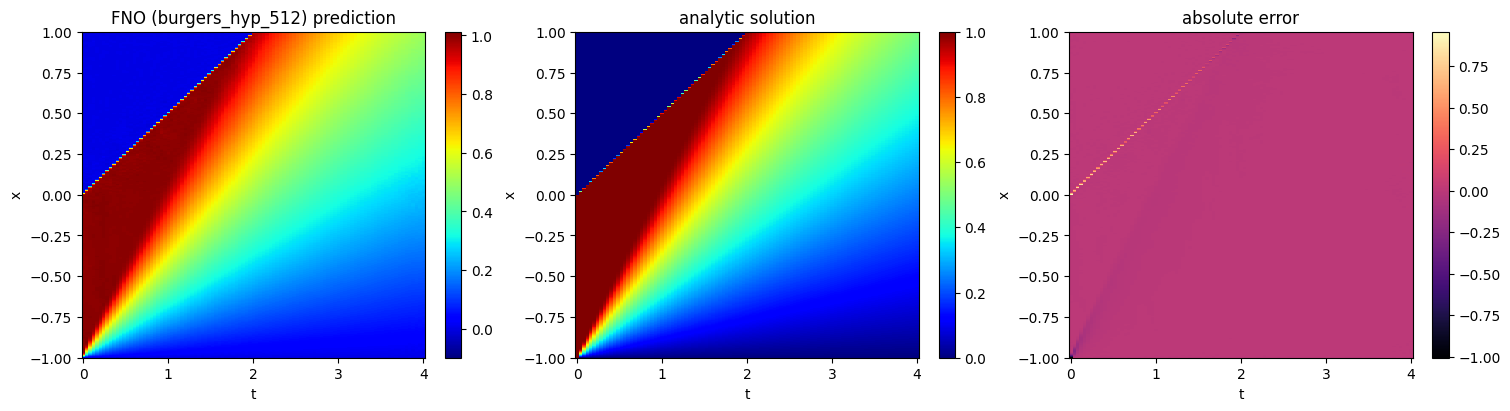

In [ ]:

fno_model = train_fno_burgers_path(f'burgers_hyp_512.mat')

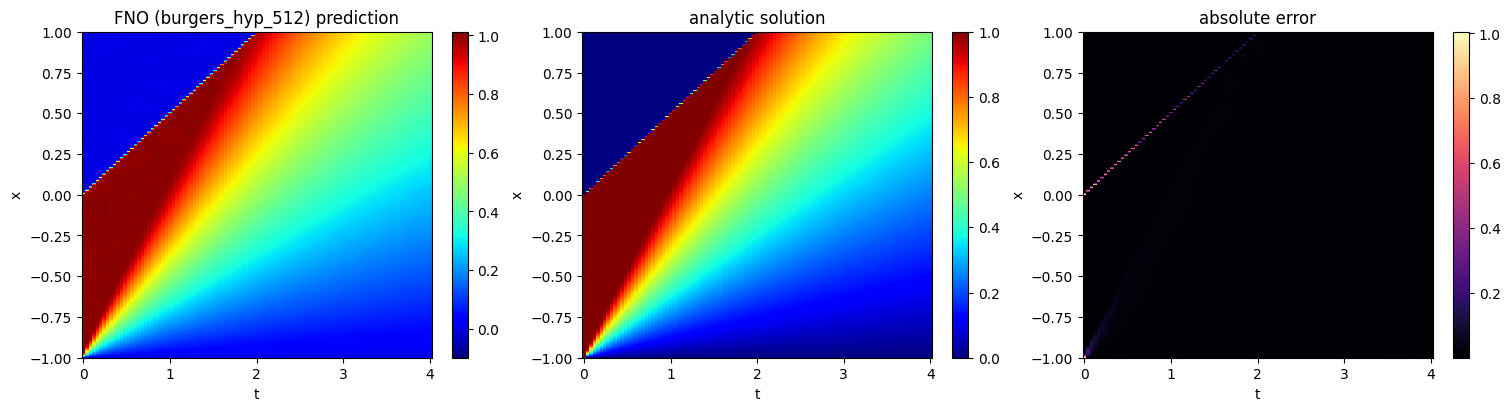

In [ ]:

plot_fno_vs_truth(fno_model, path=f'burgers_hyp.mat', title_prefix=f'FNO (burgers_hyp_512)')

### Variational PINN

Weak formulation for non-differentiable case.



In [ ]:
#

### Godunov scheme

### || Reimann problem: $ d_t u + d_x [f(u)] = 0, f(u) $ concave.
                        $ u(0,x) = a $for $ a \< 0 else b$


We know the Reimann solution: if $ u_l$ less than $u_r$, then the solution